In [1]:
from pathlib import Path
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

INPUT = Path('/kaggle/input')
WORK_DIR = Path('/kaggle/working')
OUT_DIR = WORK_DIR / 'sit3_03_kriging_moran_lisa'
FIG_DIR = OUT_DIR / 'figures'
TAB_DIR = OUT_DIR / 'tables'
for path in [OUT_DIR, FIG_DIR, TAB_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
print('OUT_DIR:', OUT_DIR)

OUT_DIR: /kaggle/working/sit3_03_kriging_moran_lisa


In [2]:
try:
    import geopandas as gpd
    import libpysal
    from esda import Moran, Moran_Local
except ImportError:
    !pip install -q geopandas libpysal esda
    import geopandas as gpd
    import libpysal
    from esda import Moran, Moran_Local

try:
    from pykrige.ok import OrdinaryKriging
except ImportError:
    !pip install -q pykrige
    from pykrige.ok import OrdinaryKriging

try:
    import gstools as gs
except ImportError:
    !pip install -q gstools
    import gstools as gs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.5/129.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.2/166.2 kB 8.2 MB/s eta 0:00:00


In [3]:
DAGMA_CANDIDATES = [
    INPUT / 'datasets/edwardsx/geovision-fuentes/dagma',
    INPUT / 'geovision-fuentes/dagma',
    INPUT / 'fuentes-proyecto-3/dagma',
    Path('/kaggle/input/datasets/juanjoseorozcolopez/geovision-fuentes/dagma'),
]
DAGMA_DIR = next((path for path in DAGMA_CANDIDATES if path.exists()), DAGMA_CANDIDATES[-1])
print('DAGMA_DIR:', DAGMA_DIR)
print('Archivos DAGMA:', sorted([path.name for path in DAGMA_DIR.glob('*')])[:30])

candidates = sorted(list(DAGMA_DIR.glob('*.parquet'))) + sorted(list(DAGMA_DIR.glob('*.csv')))
assert candidates, f'No se encontraron archivos DAGMA en {DAGMA_DIR}'
DATA_PATH = candidates[0]
print('DATA_PATH:', DATA_PATH)

if DATA_PATH.suffix == '.parquet':
    dagma = pd.read_parquet(DATA_PATH)
else:
    dagma = pd.read_csv(DATA_PATH)

print('Shape:', dagma.shape)
print('Columnas:', dagma.columns.tolist())
dagma.head()

DAGMA_DIR: /kaggle/input/datasets/juanjoseorozcolopez/geovision-fuentes/dagma
Archivos DAGMA: ['dagma_cvc_horario_raw.parquet', 'estaciones_metadata.csv', 'manifest_ground_truth.json']
DATA_PATH: /kaggle/input/datasets/juanjoseorozcolopez/geovision-fuentes/dagma/dagma_cvc_horario_raw.parquet
Shape: (107291, 14)
Columnas: ['estacion_id', 'nombre_est', 'nombre_fgda', 'msfl_code', 'med_concentracion_estandar', 'med_fecha_inicio', 'med_fecha_final', 'nombre_unidad', 'sigla_unidad', 'latitud', 'longitud', 'altitud', 'municipio', 'departamento']


,estacion_id,nombre_est,nombre_fgda,msfl_code,med_concentracion_estandar,med_fecha_inicio,med_fecha_final,nombre_unidad,sigla_unidad,latitud,longitud,altitud,municipio,departamento
0,8285,BASE AÉREA,DAGMA,O3,2.84,2020-01-21 15:00:00,2020-01-21 16:00:00,Microgramos por metro cúbico,ug/m3,3.457128,-76.502303,956,Santiago de Cali,Valle del Cauca
1,8285,BASE AÉREA,DAGMA,O3,1.20,2020-01-21 20:00:00,2020-01-21 21:00:00,Microgramos por metro cúbico,ug/m3,3.457128,-76.502303,956,Santiago de Cali,Valle del Cauca
2,8285,BASE AÉREA,DAGMA,O3,0.00,2020-01-22 00:00:00,2020-01-22 01:00:00,Microgramos por metro cúbico,ug/m3,3.457128,-76.502303,956,Santiago de Cali,Valle del Cauca
3,8285,BASE AÉREA,DAGMA,O3,0.00,2020-01-22 01:00:00,2020-01-22 02:00:00,Microgramos por metro cúbico,ug/m3,3.457128,-76.502303,956,Santiago de Cali,Valle del Cauca
4,8285,BASE AÉREA,DAGMA,O3,0.10,2020-01-22 02:00:00,2020-01-22 03:00:00,Microgramos por metro cúbico,ug/m3,3.457128,-76.502303,956,Santiago de Cali,Valle del Cauca


In [4]:
POLLUTANTS = ['NO2', 'SO2', 'O3']

COLUMN_ALIASES = {
    'station': ['estacion', 'estacion_nombre', 'station', 'nombre_estacion', 'nombre_est', 'nombre'],
    'lat': ['lat', 'latitude', 'latitud'],
    'lon': ['lon', 'longitude', 'longitud', 'lng'],
    'date': ['fecha', 'med_fecha_inicio', 'date', 'datetime', 'fecha_inicio'],
    'pollutant': ['contaminante', 'variable', 'pollutant', 'parametro', 'msfl_code', 'nombre_fgda'],
    'value': ['valor', 'concentracion', 'value', 'valor_ugm3', 'resultado', 'med_concentracion_estandar'],
}

def pick_col(df, aliases):
    lower = {col.lower(): col for col in df.columns}
    for alias in aliases:
        if alias.lower() in lower:
            return lower[alias.lower()]
    return None

cols = {key: pick_col(dagma, aliases) for key, aliases in COLUMN_ALIASES.items()}
print('Columnas detectadas:', cols)
missing = [key for key, value in cols.items() if value is None]
assert not missing, f'Columnas faltantes: {missing}. Disponibles: {dagma.columns.tolist()}'

obs = dagma.rename(columns={
    cols['station']: 'station',
    cols['lat']: 'lat',
    cols['lon']: 'lon',
    cols['date']: 'date',
    cols['pollutant']: 'pollutant',
    cols['value']: 'value',
}).copy()

obs['date'] = pd.to_datetime(obs['date'], errors='coerce')
obs['pollutant'] = (
    obs['pollutant'].astype(str)
    .str.upper()
    .str.strip()
    .str.replace('Ó', 'O', regex=False)
    .str.replace('₂', '2', regex=False)
    .str.replace('₃', '3', regex=False)
)
obs['pollutant'] = obs['pollutant'].replace({
    'DIÓXIDO DE NITRÓGENO': 'NO2',
    'DIOXIDO DE NITROGENO': 'NO2',
    'DIÓXIDO DE AZUFRE': 'SO2',
    'DIOXIDO DE AZUFRE': 'SO2',
    'OZONO': 'O3',
})
obs['value'] = pd.to_numeric(obs['value'], errors='coerce')
obs['lat'] = pd.to_numeric(obs['lat'], errors='coerce')
obs['lon'] = pd.to_numeric(obs['lon'], errors='coerce')
obs = obs[obs['pollutant'].isin(POLLUTANTS)].dropna(subset=['station', 'lat', 'lon', 'value'])
obs = obs[(obs['date'].dt.year >= 2021) & (obs['date'].dt.year <= 2024)]

print('Mediciones útiles:', len(obs))
print(obs.groupby('pollutant')['station'].nunique())
obs.head()

Columnas detectadas: {'station': 'nombre_est', 'lat': 'latitud', 'lon': 'longitud', 'date': 'med_fecha_inicio', 'pollutant': 'msfl_code', 'value': 'med_concentracion_estandar'}
Mediciones útiles: 55099
pollutant
NO2    1
O3     7
SO2    4
Name: station, dtype: int64


,estacion_id,station,nombre_fgda,pollutant,value,date,med_fecha_final,nombre_unidad,sigla_unidad,lat,lon,altitud,municipio,departamento
3183,8285,BASE AÉREA,DAGMA,O3,0.73,2021-07-09 22:00:00,2021-07-09 23:00:00,Microgramos por metro cúbico,ug/m3,3.457128,-76.502303,956,Santiago de Cali,Valle del Cauca
3184,8285,BASE AÉREA,DAGMA,O3,0.80,2021-07-10 00:00:00,2021-07-10 01:00:00,Microgramos por metro cúbico,ug/m3,3.457128,-76.502303,956,Santiago de Cali,Valle del Cauca
3185,8285,BASE AÉREA,DAGMA,O3,0.63,2021-07-10 01:00:00,2021-07-10 02:00:00,Microgramos por metro cúbico,ug/m3,3.457128,-76.502303,956,Santiago de Cali,Valle del Cauca
3186,8285,BASE AÉREA,DAGMA,O3,0.80,2021-07-10 03:00:00,2021-07-10 04:00:00,Microgramos por metro cúbico,ug/m3,3.457128,-76.502303,956,Santiago de Cali,Valle del Cauca
3187,8285,BASE AÉREA,DAGMA,O3,0.82,2021-07-10 04:00:00,2021-07-10 05:00:00,Microgramos por metro cúbico,ug/m3,3.457128,-76.502303,956,Santiago de Cali,Valle del Cauca


In [5]:
station_obs = (
    obs.groupby(['pollutant', 'station'], as_index=False)
    .agg(lat=('lat', 'mean'), lon=('lon', 'mean'), value=('value', 'mean'), n=('value', 'size'))
)
station_obs.to_csv(TAB_DIR / 'station_pollutant_means.csv', index=False)
print(station_obs.groupby('pollutant')['station'].nunique())
station_obs

pollutant
NO2    1
O3     7
SO2    4
Name: station, dtype: int64


,pollutant,station,lat,lon,value,n
0,NO2,ESTACIÓN YUMBO,3.579075,-76.489558,10.732291,4985
1,O3,BASE AÉREA,3.457128,-76.502303,9.106060,4127
2,O3,COMPARTIR,3.428260,-76.466584,14.180059,3383
3,O3,ERA OBRERO,3.457317,-76.506539,14.463354,1917
4,O3,ESTACIÓN YUMBO,3.579075,-76.489558,20.722907,12756
5,O3,LA FLORA,3.488218,-76.518058,16.742883,1575
6,O3,PANCE,3.304517,-76.531252,26.351275,2369
7,O3,UNIVERSIDAD DEL VALLE,3.377911,-76.533811,11.792405,4249
8,SO2,BASE AÉREA,3.457128,-76.502303,7.652939,3229
9,SO2,CAÑAVERALEJO,3.416366,-76.549613,2.483993,1678


In [6]:
def loo_ordinary_kriging(df_poll, variogram_model='exponential'):
    rows = []
    df_poll = df_poll.reset_index(drop=True)
    if len(df_poll) < 3:
        return pd.DataFrame()

    for idx in range(len(df_poll)):
        train = df_poll.drop(index=idx).reset_index(drop=True)
        test = df_poll.iloc[idx]
        method = 'ordinary_kriging'
        try:
            ok = OrdinaryKriging(
                train['lon'].to_numpy(),
                train['lat'].to_numpy(),
                train['value'].to_numpy(),
                variogram_model=variogram_model,
                verbose=False,
                enable_plotting=False,
            )
            pred, var = ok.execute('points', np.array([test['lon']]), np.array([test['lat']]))
            pred_value = float(np.asarray(pred)[0])
            pred_var = float(np.asarray(var)[0])
        except Exception as exc:
            method = f'train_mean_fallback: {type(exc).__name__}'
            pred_value = float(train['value'].mean())
            pred_var = float(train['value'].var(ddof=1)) if len(train) > 1 else np.nan
            print(f'Fallback mean for {test["pollutant"]} / {test["station"]}: {exc}')

        rows.append({
            'pollutant': test['pollutant'],
            'station': test['station'],
            'lat': float(test['lat']),
            'lon': float(test['lon']),
            'y_true': float(test['value']),
            'y_pred': pred_value,
            'kriging_var': pred_var,
            'abs_error': abs(float(test['value']) - pred_value),
            'method': method,
        })
    return pd.DataFrame(rows)

In [7]:
loo_results = []
for poll in POLLUTANTS:
    dfp = station_obs[station_obs['pollutant'] == poll].copy()
    res = loo_ordinary_kriging(dfp)
    if len(res) == 0:
        print(f'{poll}: no evaluable con {len(dfp)} estaciones')
    else:
        loo_results.append(res)

loo_df = pd.concat(loo_results, ignore_index=True) if loo_results else pd.DataFrame()
loo_df.to_csv(TAB_DIR / 'loo_kriging_predictions.csv', index=False)
loo_df

NO2: no evaluable con 1 estaciones


,pollutant,station,lat,lon,y_true,y_pred,kriging_var,abs_error,method
0,SO2,BASE AÉREA,3.457128,-76.502303,7.652939,4.389548,39.908575,3.263391,ordinary_kriging
1,SO2,CAÑAVERALEJO,3.416366,-76.549613,2.483993,6.419152,38.950253,3.935159,ordinary_kriging
2,SO2,ESTACIÓN YUMBO,3.579075,-76.489558,13.118863,4.180048,17.287937,8.938815,ordinary_kriging
3,SO2,LA ERMITA,3.455514,-76.530978,2.403212,6.340035,11.501260,3.936823,ordinary_kriging
4,O3,BASE AÉREA,3.457128,-76.502303,9.106060,16.303946,37.623203,7.197886,ordinary_kriging
5,O3,COMPARTIR,3.428260,-76.466584,14.180059,14.652320,33.148383,0.472261,ordinary_kriging
6,O3,ERA OBRERO,3.457317,-76.506539,14.463354,16.482597,49.959533,2.019243,ordinary_kriging
7,O3,ESTACIÓN YUMBO,3.579075,-76.489558,20.722907,17.137304,37.986285,3.585603,ordinary_kriging
8,O3,LA FLORA,3.488218,-76.518058,16.742883,15.451331,25.921565,1.291552,ordinary_kriging
9,O3,PANCE,3.304517,-76.531252,26.351275,14.472562,28.983237,11.878712,ordinary_kriging


In [8]:
def regression_metrics(df):
    if len(df) < 2:
        return {'n': int(len(df)), 'rmse': np.nan, 'mae': np.nan, 'r2': np.nan}
    return {
        'n': int(len(df)),
        'rmse': float(root_mean_squared_error(df['y_true'], df['y_pred'])),
        'mae': float(mean_absolute_error(df['y_true'], df['y_pred'])),
        'r2': float(r2_score(df['y_true'], df['y_pred'])),
    }

metrics_rows = []
for poll in POLLUTANTS:
    dfp = loo_df[loo_df['pollutant'] == poll]
    metrics_rows.append({'pollutant': poll, **regression_metrics(dfp)})
metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv(TAB_DIR / 'loo_kriging_metrics.csv', index=False)
metrics_df

,pollutant,n,rmse,mae,r2
0,NO2,0,NaN,NaN,NaN
1,SO2,4,5.512173,5.018547,-0.557726
2,O3,7,6.262576,4.909992,-0.368272


In [9]:
coverage_df = loo_df.copy()
coverage_df['sigma'] = np.sqrt(np.maximum(coverage_df['kriging_var'], 0))
coverage_df['lo95'] = coverage_df['y_pred'] - 1.96 * coverage_df['sigma']
coverage_df['hi95'] = coverage_df['y_pred'] + 1.96 * coverage_df['sigma']
coverage_df['covered95'] = (coverage_df['y_true'] >= coverage_df['lo95']) & (coverage_df['y_true'] <= coverage_df['hi95'])
coverage_summary = (
    coverage_df.groupby('pollutant', as_index=False)
    .agg(n=('covered95', 'size'), coverage95=('covered95', 'mean'))
)
coverage_df.to_csv(TAB_DIR / 'loo_kriging_coverage_rows.csv', index=False)
coverage_summary.to_csv(TAB_DIR / 'loo_kriging_coverage_summary.csv', index=False)

for _, row in coverage_summary.iterrows():
    status = 'cumple' if row['coverage95'] >= 0.92 else 'no cumple'
    print(f"{row['pollutant']}: cobertura 95%={row['coverage95']:.3f} ({status}, n={int(row['n'])})")
coverage_summary

O3: cobertura 95%=0.857 (no cumple, n=7)
SO2: cobertura 95%=0.750 (no cumple, n=4)


,pollutant,n,coverage95
0,O3,7,0.857143
1,SO2,4,0.750000


In [10]:
resid_df = loo_df.copy()
resid_df['residual'] = resid_df['y_true'] - resid_df['y_pred']
resid_df.to_csv(TAB_DIR / 'loo_residuals.csv', index=False)

variogram_rows = []
for poll in POLLUTANTS:
    dfp = resid_df[resid_df['pollutant'] == poll].dropna(subset=['residual'])
    if len(dfp) < 4:
        print(f'{poll}: variograma no robusto con n={len(dfp)}')
        continue
    x = dfp['lon'].to_numpy()
    y = dfp['lat'].to_numpy()
    z = dfp['residual'].to_numpy()
    try:
        bin_center, gamma = gs.vario_estimate((x, y), z)
        model = gs.Exponential(dim=2)
        model.fit_variogram(bin_center, gamma, nugget=True)
        nugget_ratio = float(model.nugget / (model.nugget + model.var)) if (model.nugget + model.var) > 0 else np.nan
        variogram_rows.append({
            'pollutant': poll,
            'n': int(len(dfp)),
            'var': float(model.var),
            'len_scale': float(model.len_scale),
            'nugget': float(model.nugget),
            'nugget_ratio': nugget_ratio,
        })
        ax = model.plot(x_max=max(bin_center))
        ax.scatter(bin_center, gamma, label='experimental')
        ax.set_title(f'Variograma residuos {poll}')
        ax.legend()
        plt.savefig(FIG_DIR / f'variograma_residuos_{poll}.png', dpi=160, bbox_inches='tight')
        plt.close()
    except Exception as exc:
        print(f'{poll}: error variograma: {exc}')

variogram_df = pd.DataFrame(variogram_rows)
variogram_df.to_csv(TAB_DIR / 'residual_variogram_summary.csv', index=False)
variogram_df

NO2: variograma no robusto con n=0


,pollutant,n,var,len_scale,nugget,nugget_ratio
0,SO2,4,1.736852,178.426937,0.257794,0.129243
1,O3,7,6296.888640,178.589345,11.972062,0.001898


In [11]:
lat_grid = np.arange(3.30, 3.55 + 1e-9, 0.005)
lon_grid = np.arange(-76.60, -76.40 + 1e-9, 0.005)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
grid_points = pd.DataFrame({'lon': lon_mesh.ravel(), 'lat': lat_mesh.ravel()})
print('Grid points:', grid_points.shape)
grid_points.head()

Grid points: (2091, 2)


,lon,lat
0,-76.600,3.3
1,-76.595,3.3
2,-76.590,3.3
3,-76.585,3.3
4,-76.580,3.3


In [12]:
grid_outputs = []
for poll in POLLUTANTS:
    dfp = station_obs[station_obs['pollutant'] == poll].copy()
    if len(dfp) < 3:
        print(f'{poll}: superficie no generada con n={len(dfp)}')
        continue
    ok = OrdinaryKriging(
        dfp['lon'].to_numpy(),
        dfp['lat'].to_numpy(),
        dfp['value'].to_numpy(),
        variogram_model='exponential',
        verbose=False,
        enable_plotting=False,
    )
    z, var = ok.execute('points', grid_points['lon'].to_numpy(), grid_points['lat'].to_numpy())
    out = grid_points.copy()
    out['pollutant'] = poll
    out['prediction'] = np.asarray(z, dtype=float)
    out['variance'] = np.asarray(var, dtype=float)
    out['sigma'] = np.sqrt(np.maximum(out['variance'], 0))
    grid_outputs.append(out)

grid_pred = pd.concat(grid_outputs, ignore_index=True) if grid_outputs else pd.DataFrame()
grid_pred.to_parquet(OUT_DIR / 'kriging_grid_predictions.parquet', index=False)
print(grid_pred.groupby('pollutant').size())
grid_pred.head()

NO2: superficie no generada con n=1
pollutant
O3     2091
SO2    2091
dtype: int64


,lon,lat,pollutant,prediction,variance,sigma
0,-76.600,3.3,SO2,7.035296,29.658450,5.445957
1,-76.595,3.3,SO2,7.018700,29.570522,5.437878
2,-76.590,3.3,SO2,7.003427,29.486310,5.430130
3,-76.585,3.3,SO2,6.989689,29.406761,5.422800
4,-76.580,3.3,SO2,6.977691,29.332817,5.415978


In [13]:
def moran_for_grid(df_poll, k=8):
    coords = df_poll[['lon', 'lat']].to_numpy()
    w = libpysal.weights.KNN.from_array(coords, k=k)
    w.transform = 'r'
    y = df_poll['prediction'].to_numpy()
    moran = Moran(y, w, permutations=999)
    lisa = Moran_Local(y, w, permutations=999)
    result = {
        'pollutant': df_poll['pollutant'].iloc[0],
        'n': int(len(df_poll)),
        'moran_i': float(moran.I),
        'expected_i': float(moran.EI),
        'p_sim': float(moran.p_sim),
        'z_sim': float(moran.z_sim),
        'significant_positive': bool((moran.I > 0.30) and (moran.p_sim < 0.05)),
    }
    lisa_df = df_poll.copy()
    lisa_df['local_i'] = lisa.Is
    lisa_df['lisa_q'] = lisa.q
    lisa_df['lisa_p_sim'] = lisa.p_sim
    lisa_df['lisa_significant'] = lisa.p_sim < 0.05
    return result, lisa_df

In [14]:
moran_rows = []
lisa_outputs = []
for poll in sorted(grid_pred['pollutant'].unique()):
    dfp = grid_pred[grid_pred['pollutant'] == poll].reset_index(drop=True)
    result, lisa_df = moran_for_grid(dfp)
    moran_rows.append(result)
    lisa_outputs.append(lisa_df)

moran_df = pd.DataFrame(moran_rows)
lisa_grid = pd.concat(lisa_outputs, ignore_index=True) if lisa_outputs else pd.DataFrame()
moran_df.to_csv(TAB_DIR / 'moran_global.csv', index=False)
lisa_grid.to_parquet(OUT_DIR / 'lisa_grid.parquet', index=False)
print(moran_df)

cluster_labels = {1: 'High-High', 2: 'Low-High', 3: 'Low-Low', 4: 'High-Low'}
lisa_summary = (
    lisa_grid[lisa_grid['lisa_significant']]
    .assign(cluster=lambda df: df['lisa_q'].map(cluster_labels))
    .groupby(['pollutant', 'cluster'], as_index=False)
    .size()
)
lisa_summary.to_csv(TAB_DIR / 'lisa_cluster_summary.csv', index=False)
lisa_summary

  pollutant     n   moran_i  expected_i  p_sim      z_sim  \
0        O3  2091  0.988773   -0.000478  0.001  94.159932   
1       SO2  2091  0.991964   -0.000478  0.001  89.517339   

   significant_positive  
0                  True  
1                  True  


,pollutant,cluster,size
0,O3,High-High,468
1,O3,Low-Low,552
2,SO2,High-High,561
3,SO2,Low-Low,482


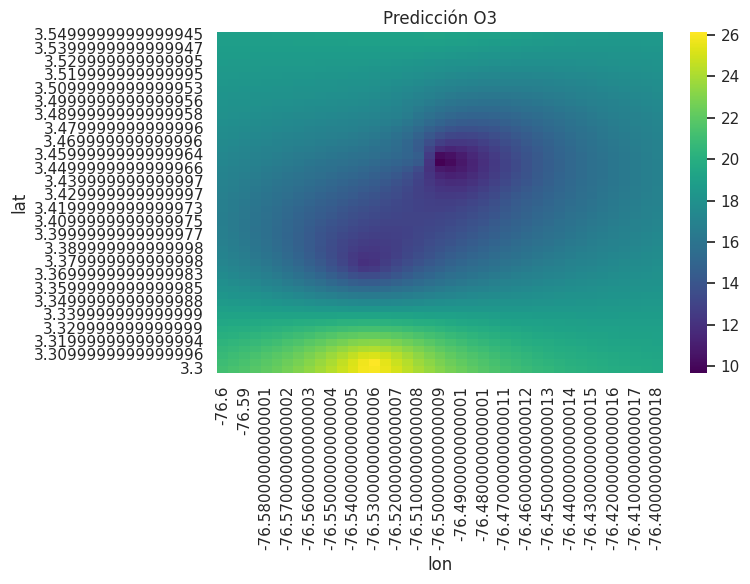

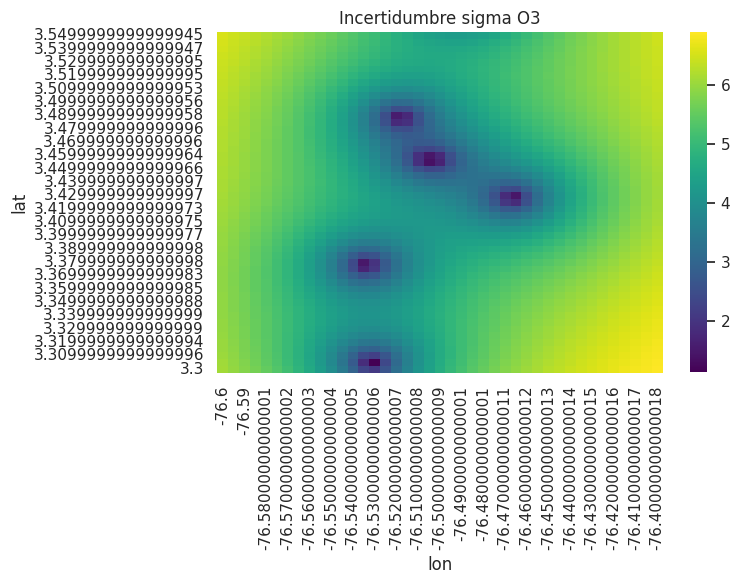

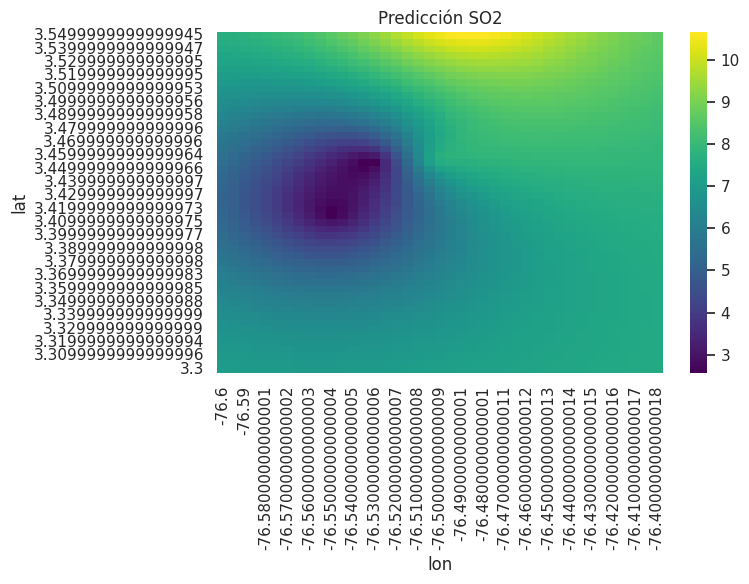

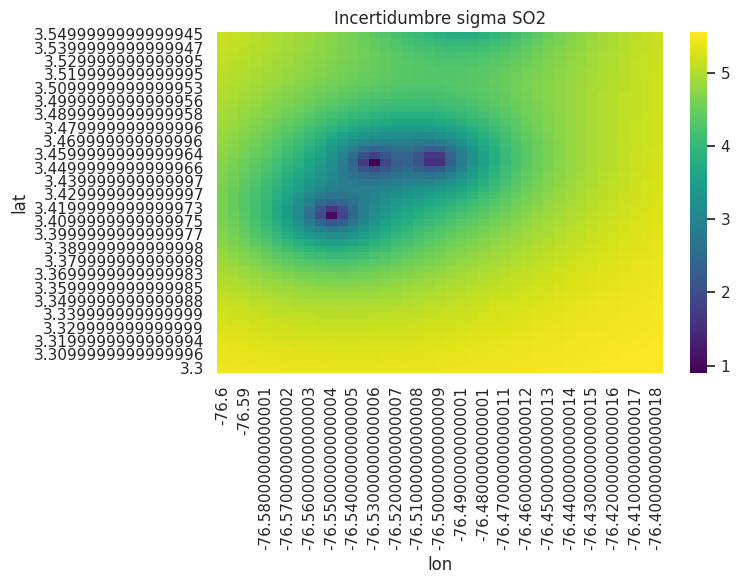

In [15]:
for poll in sorted(grid_pred['pollutant'].unique()):
    dfp = grid_pred[grid_pred['pollutant'] == poll]
    for col, title in [('prediction', 'Predicción'), ('sigma', 'Incertidumbre sigma')]:
        pivot = dfp.pivot(index='lat', columns='lon', values=col)
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot.sort_index(ascending=False), cmap='viridis')
        plt.title(f'{title} {poll}')
        plt.xlabel('lon')
        plt.ylabel('lat')
        plt.tight_layout()
        plt.savefig(FIG_DIR / f'{col}_{poll}.png', dpi=160, bbox_inches='tight')
        plt.show()

In [16]:
kpi_rows = []
for _, row in metrics_df.iterrows():
    poll = row['pollutant']
    target = {'NO2': 8.0, 'SO2': 6.0, 'O3': 12.0}[poll]
    kpi_rows.append({
        'kpi': f'RMSE LOO-CV {poll} T+1',
        'target': target,
        'value': row['rmse'],
        'passes': bool(pd.notna(row['rmse']) and row['rmse'] <= target),
    })

for _, row in moran_df.iterrows():
    kpi_rows.append({
        'kpi': f'Moran I {row["pollutant"]}',
        'target': '>0.30 and p<0.05',
        'value': f"I={row['moran_i']:.3f}, p={row['p_sim']:.3f}",
        'passes': bool(row['significant_positive']),
    })

for _, row in coverage_summary.iterrows():
    kpi_rows.append({
        'kpi': f'Cobertura 95% {row["pollutant"]}',
        'target': 0.92,
        'value': row['coverage95'],
        'passes': bool(row['coverage95'] >= 0.92),
    })

kpi_df = pd.DataFrame(kpi_rows)
kpi_df.to_csv(TAB_DIR / 'sit3_kpi_summary.csv', index=False)
kpi_df

,kpi,target,value,passes
0,RMSE LOO-CV NO2 T+1,8.0,NaN,False
1,RMSE LOO-CV SO2 T+1,6.0,5.512173,True
2,RMSE LOO-CV O3 T+1,12.0,6.262576,True
3,Moran I O3,>0.30 and p<0.05,"I=0.989, p=0.001",True
4,Moran I SO2,>0.30 and p<0.05,"I=0.992, p=0.001",True
5,Cobertura 95% O3,0.92,0.857143,False
6,Cobertura 95% SO2,0.92,0.75,False


In [17]:
manifest = {
    'notebook': '03_sit3_kriging_moran_lisa.ipynb',
    'out_dir': str(OUT_DIR),
    'tables': sorted([path.name for path in TAB_DIR.glob('*')]),
    'figures': sorted([path.name for path in FIG_DIR.glob('*')]),
}
(OUT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))

{
  "notebook": "03_sit3_kriging_moran_lisa.ipynb",
  "out_dir": "/kaggle/working/sit3_03_kriging_moran_lisa",
  "tables": [
    "lisa_cluster_summary.csv",
    "loo_kriging_coverage_rows.csv",
    "loo_kriging_coverage_summary.csv",
    "loo_kriging_metrics.csv",
    "loo_kriging_predictions.csv",
    "loo_residuals.csv",
    "moran_global.csv",
    "residual_variogram_summary.csv",
    "sit3_kpi_summary.csv",
    "station_pollutant_means.csv"
  ],
  "figures": [
    "prediction_O3.png",
    "prediction_SO2.png",
    "sigma_O3.png",
    "sigma_SO2.png",
    "variograma_residuos_O3.png",
    "variograma_residuos_SO2.png"
  ]
}
